## Set Up

In [1]:
#!pip install pandas
#!pip install numpy
#!pip install matplotlib
#!pip install seaborn

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

    ## Preparing Data

### Reading Data

In [156]:
# Reading in Data
df = pd.read_csv(Path.cwd() / "Data" / "Raw" / "insurance_dataset.csv",
                 dtype={"is_capped_incurred":"Int64",
                        "bi_count":"Int64",
                        "ad_count":"Int64",
                        "pd_count":"Int64",
                        "th_count":"Int64",
                        "ws_count":"Int64",
                        "vehicle_age":"Int64"})

# Converting dates and times
df["start_date"] = pd.to_datetime(df["start_date"], format = "mixed")
df["vehicle_purchase_date"] = pd.to_datetime(df["vehicle_purchase_date"], format = "mixed")
df["licence_test_date"] = pd.to_datetime(df["licence_test_date"], format = "mixed")

### Profiling Missing Data 1

In [157]:
# Profiling missing values
missing_values_before = (
    pd.DataFrame(df.isna()
                 .sum())
    .reset_index()
    .rename(columns={"index":"Column",
                     0:"Values Missing"})
    .sort_values("Values Missing", ascending=False)
)

# Exporting Missing Values Report
#missing_values_before.to_csv(Path.cwd() / "Reports" / "missing_values_before.csv", index=False)

### Difficult Data Quality Issues

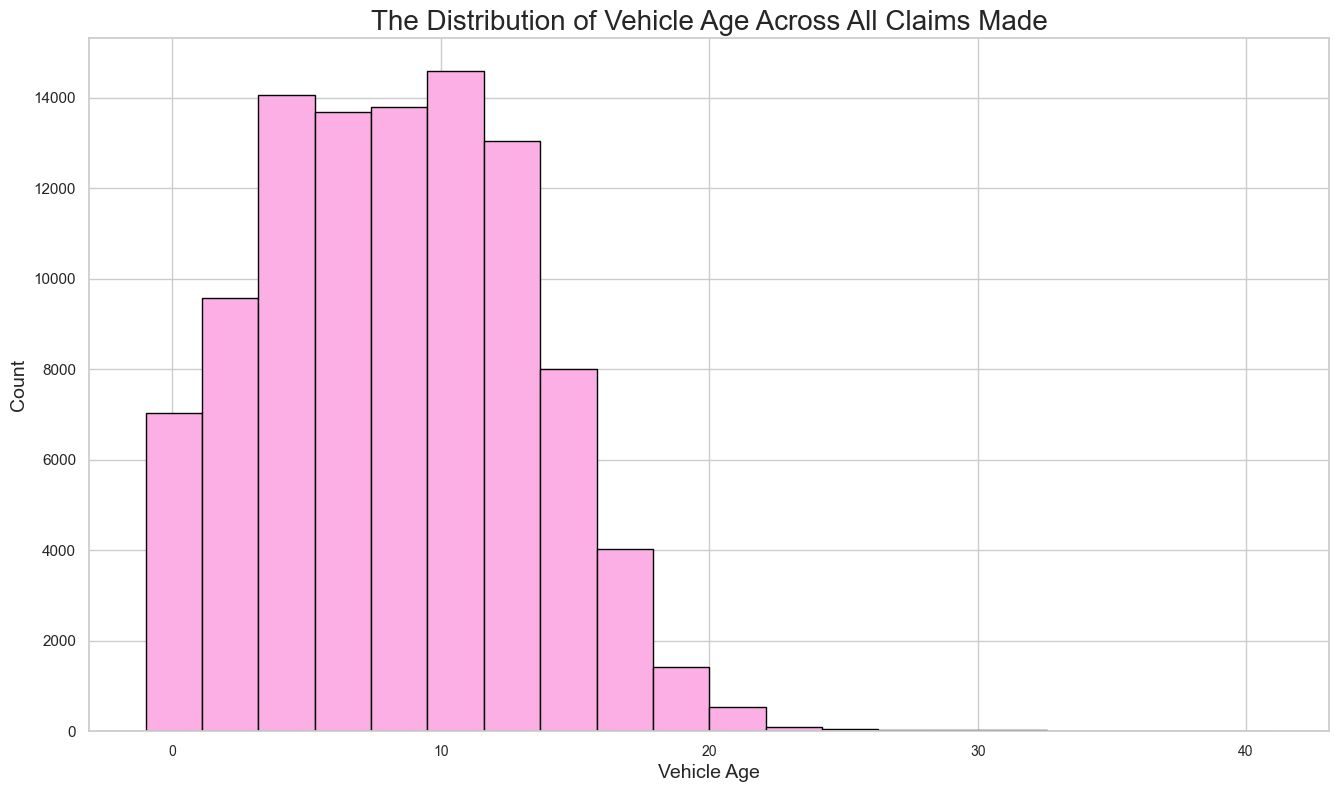

In [158]:
fig = plt.figure(figsize = (16,9))

sns.set_theme(style = "whitegrid")

plt.hist(df["vehicle_age"],
        edgecolor = "black",
        bins = 20,
        color = sns.color_palette("colorblind")[6])

plt.xlabel("Vehicle Age", fontsize = 14)
plt.ylabel("Count", fontsize = 14)
plt.title("The Distribution of Vehicle Age Across All Claims Made", fontsize = 20)
plt.xticks(fontsize = 10)

plt.show()

sns.set_theme(style = "whitegrid")

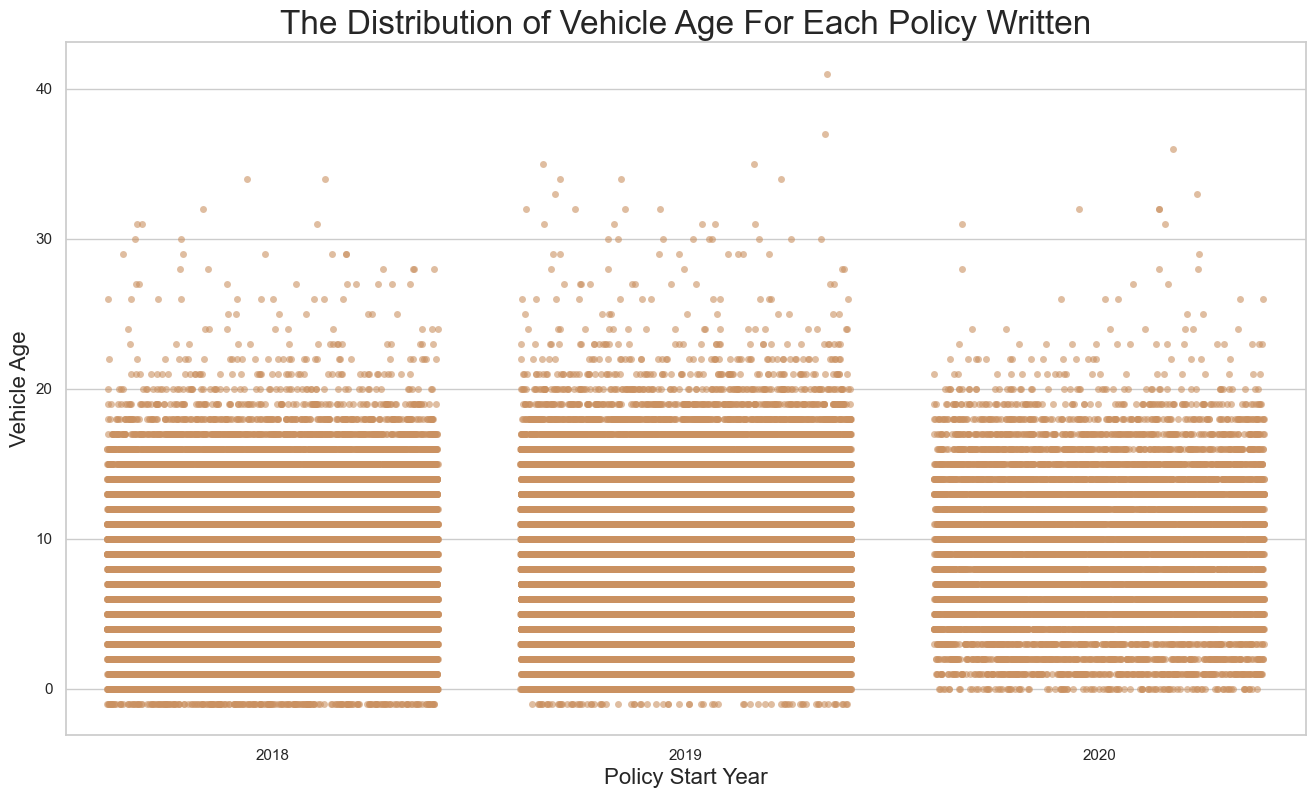

In [159]:
# Creating a Year column for aggregation
df["start_year"] = df["start_date"].dt.year.astype("category")
df["start_year"] = df["start_year"].cat.reorder_categories([2018, 2019, 2020])

fig = plt.figure(figsize = (16, 9))

sns.set_theme(style = "whitegrid")

sns.stripplot(data = df,
              x = "start_year",
              y = "vehicle_age",
             jitter = 0.4,
              alpha = 0.6,
             color = sns.color_palette("colorblind")[5])

plt.xlabel("Policy Start Year", fontsize = 16),
plt.ylabel("Vehicle Age", fontsize = 16)
plt.title("The Distribution of Vehicle Age For Each Policy Written", fontsize = 24)

plt.show()

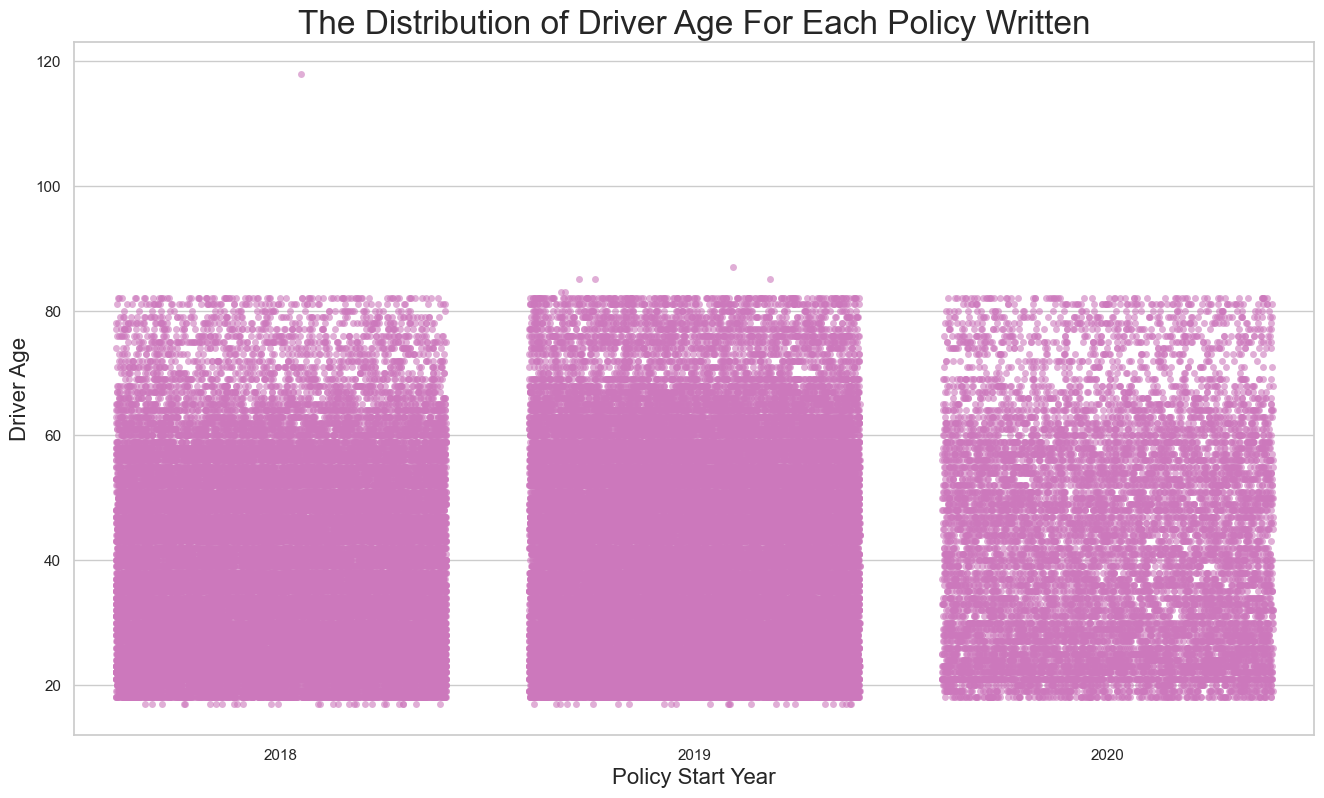

In [160]:
fig = plt.figure(figsize = (16, 9))

sns.set_theme(style = "whitegrid")

sns.stripplot(data = df,
              x = "start_year",
              y = "d1_age",
             jitter = 0.4,
              alpha = 0.6,
             color = sns.color_palette("colorblind")[4])

plt.xlabel("Policy Start Year", fontsize = 16),
plt.ylabel("Driver Age", fontsize = 16)
plt.title("The Distribution of Driver Age For Each Policy Written", fontsize = 24)

plt.show()

In [178]:
neg_incurred = (
    (df.loc[:, list(df.columns[df.columns.str.endswith("incurred")][1:])] < 0)
        .sum()
        .reset_index()
        .rename(columns = {"index":"Column", 0:"Total Negative Values"})
        .sort_values("Total Negative Values", ascending = False)
)

neg_incurred
#neg_incurred.to_csv(Path.cwd() / "Reports" / "negative_incurred.csv", index = False)

### Replacing Values

In [118]:
## Replacing Values

#Cleaning up the name of business providers
df["business_provider"] = df["business_provider"].str.replace({" ":"",
                                                               "+":"and",
                                                               "DefaultDefault":"Default",
                                                               "DefaultCampaign":"Default"})


#Replacing age 118 with NaN
df["d1_age"] = df["d1_age"].where(df["d1_age"] != 118)

df["d1_residency_years"] = df["d1_residency_years"].where(df["d1_residency_years"] != 118)

#Replacing NA with 0
df["incurred"] = df["incurred"].fillna(0)
df["capped_incurred"] = df["capped_incurred"].fillna(0)
df["bi_incurred"] = df["bi_incurred"].fillna(0)
df["ad_incurred"] = df["ad_incurred"].fillna(0)
df["pd_incurred"] = df["pd_incurred"].fillna(0)
df["th_incurred"] = df["th_incurred"].fillna(0)
df["ws_incurred"] = df["ws_incurred"].fillna(0)

df["bi_count"] = df["bi_count"].fillna(0)
df["ad_count"] = df["ad_count"].fillna(0)
df["pd_count"] = df["pd_count"].fillna(0)
df["th_count"] = df["th_count"].fillna(0)
df["ws_count"] = df["ws_count"].fillna(0)

df["is_capped_incurred"] = df["is_capped_incurred"].fillna(0)


#Calculating absolute values of all negative "incurred" values and Recalculating the incurred column
df["ad_incurred"] = df["ad_incurred"].abs()
df["th_incurred"] = df["th_incurred"].abs()
df["pd_incurred"] = df["pd_incurred"].abs()

df["incurred"] = df["ad_incurred"] + df["bi_incurred"] + df["pd_incurred"] + df["th_incurred"] + df["ws_incurred"]

df["capped_incurred"] = np.select(
    [
        (df["is_capped_incurred"] == 1) &
        (df["incurred"] != df["capped_incurred"]) &
        (df["incurred"] < 50000),
        (df["is_capped_incurred"] == 1) &
        (df["incurred"] != df["capped_incurred"]) &
        (df["incurred"] >= 50000)
    ],
    [
        df["incurred"],
        50000
    ],
    df["capped_incurred"]
)    


#Filling in NAs for net_earned_premium
df["net_earned_premium"] = df["net_earned_premium"].where(~df["net_earned_premium"].isna(),
                                                         df["net_written_premium"] * df["exposure"])


#Replacing negatives values with NaN
df["vehicle_age"] = df["vehicle_age"].where(df["vehicle_age"] >= 0)

#df["ad_incurred"] = df["ad_incurred"].where(df["ad_incurred"] >= 0)

#df["th_incurred"] = df["th_incurred"].where(df["th_incurred"] >= 0)

#df["incurred"] = df["incurred"].where(df["incurred"] >= 0)

#df["capped_incurred"] = df["capped_incurred"].where(df["capped_incurred"] >= 0)


## Changing Casing
df["vehicle_make"] = df["vehicle_make"].str.title()

df["transmission"] = df["transmission"].str.title()

### Checking Duplicates

In [119]:
# Checking for duplicate rows
print(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns")

print(f"{df.duplicated().sum()} rows are duplicated")

print(f"{df["id"].duplicated().sum()} ID values are duplicated")


Dataset has 100000 rows and 41 columns
0 rows are duplicated
0 ID values are duplicated


### Checking Values

In [155]:
# Checking column values
#df.groupby("ws_incurred").groups.keys()

#### Looking at the values in each column, below are issues that should be addressed:

*Data Types*
- is_capped_incurred is float
- bi_count is float
- ad_count is float
- pd_count is float
- th_count is float
- ws_count is float
- vehicle_age is float

*Numeric Values*
- ad_incurred has negative values
- th_incurred has negative values
- incurred has negative values
- capped_incurred has negative values
- d1_age contains "118" values.
- d1_residency_years contains "118" values
- vehicle_value has a range of values, including single digits (not decided)
- vehicle_age contains negative values

*Character Values*
- business_provider has multiple formats for values (may be more work)
- vehicle_make is all capitalised
- transmission is all capitalised

### Profiling Missing Data 2

In [121]:
# Profiling missing values
missing_values_after = (
    pd.DataFrame(df.isna()
                 .sum())
    .reset_index()
    .rename(columns={"index":"Column",
                     0:"Values Missing"})
    .sort_values("Values Missing", ascending=False)
)

# Exporting Missing Values Report
#missing_values_after.to_csv(Path.cwd() / "Reports" / "missing_values_after.csv", index=False)

## High-Level Analysis

### Number of Policies Written

In [122]:
# Creating a Year column for aggregation
#df["start_year"] = df["start_date"].dt.year.astype("category")
#df["start_year"] = df["start_year"].cat.reorder_categories([2018, 2019, 2020])

policies = (
    df.groupby("start_year").id.count()
        .reset_index()
        .rename(columns = {"start_year":"Start Year", "id":"Number of Policies"})
)

policies
#policies.to_csv(Path.cwd() / "Reports" / "policies.csv", index = False)

,Start Year,Number of Policies
0,2018,38539
1,2019,49808
2,2020,11653


Policies written in 2020 could be low due to Covid and fewer people driving/more people working from home

### Frequency of Claims Counts

In [123]:
# Frequency of claims count
claim_frequency = pd.DataFrame(df.groupby("claim_count")
                               .id
                               .count()
                               .reset_index()
                               .rename(columns={"claim_count":"Claims Count",
                                                "id": "Frequency"}))

claim_frequency["Percentage"] = (claim_frequency["Frequency"] / claim_frequency["Frequency"].sum()) * 100
claim_frequency
# Exporting
#claim_frequency.to_csv("Reports/claim_frequency.csv", index=False)

,Claims Count,Frequency,Percentage
0,0,92581,92.581
1,1,6937,6.937
2,2,452,0.452
3,3,27,0.027
4,4,3,0.003


### Profit

In [124]:
# Calculating the total cost per person
df["final_incurred"] = np.where(df["is_capped_incurred"].fillna(0) == 1,
                                df["capped_incurred"],
                                df["incurred"])

# Calculating Profitability
df["profit"] = df["net_earned_premium"].fillna(0) - df["final_incurred"].fillna(0)

print(f"The gross earned premiums is {round(df["net_earned_premium"].sum(), 2)}")
print(f"The total incurred charges is {round(df["final_incurred"].sum(), 2)}")
print(f"Total profit made in this period is {round(df['profit'].sum(), 2)}")

The gross earned premiums is 27237225.85
The total incurred charges is 19587515.21
Total profit made in this period is 7649710.64


### Claims Frequency

In [ ]:
# Calculating Claims Frequency
claims_frequency = df["claim_count"].sum() / df["exposure"].sum()

print(f"The total number of claims is {df["claim_count"].sum()}")
print(f"The total number of vehicles vehicle-years at risk is {round(df['exposure'].sum(), 2)}")
print(f"The claims frequency is {round(claims_frequency, 2)} claims per year")

## Profiling Customer Who Made Claims

### Number of Claims by Policy Year

In [ ]:
# Calculating number of claims by start_year and the number of people making claims

yearly_claims = (
    pd.merge(left = df.groupby("start_year").claim_count.sum().reset_index(),
        right = df[df["claim_count"] > 0].groupby("start_year").id.count().reset_index(),
        on = "start_year")
    .rename(columns={"start_year":"Start Year",
                     "claim_count":"Total Claims",
                     "id":"Number of Customers",})
)

yearly_claims

### Average Claim Value

In [ ]:
# Subsetting customers that made claims
df_claimed = df[df["claim_count"] > 0]

print(f"{df_claimed.shape[0]} customers made a claim")

# Calculating the average cost per claim
df_claimed["mean_claim_value"] = df_claimed["final_incurred"] / df_claimed["claim_count"]

print(f"The average claim value is {round(df_claimed["final_incurred"].mean(), 2)}")

In [ ]:
# Calculating the average claim cost each year
mean_claim_by_year = df_claimed.groupby("start_year").mean_claim_value.mean().reset_index()

fig = plt.figure(figsize=(16, 9))

sns.catplot(data = mean_claim_by_year,
            x = "start_year",
            y = "mean_claim_value",
            kind = "bar",
            color = sns.color_palette("Set2")[0])

plt.xlabel("Start Year", fontsize=16)
plt.ylabel("Mean Claim Value (£)", fontsize=16)
plt.xticks(fontsize=14)
plt.axhline(y=round(df_claimed["final_incurred"].mean(), 2),
            color = sns.color_palette("Set2")[1],
            linestyle="--")
plt.text(x=-0.45,
         y=round(df_claimed["final_incurred"].mean(), 2) + 30,
         s=str(round(df_claimed["final_incurred"].mean(), 2)),
         fontsize=8,
         color="black")

for i, v in enumerate(mean_claim_by_year["mean_claim_value"]):
    plt.text(i, v, str(round(v, 2)), ha = "center", va = "bottom")

plt.show()

### Type of Claims Made

In [ ]:
# Distribution of claim type
claims_by_type = (
    df_claimed.loc[:, ["bi_count", "ad_count", "pd_count", "th_count", "ws_count"]].sum()
    .reset_index()
)
claims_by_type.columns = ["Type", "Frequency"]
claims_by_type = claims_by_type.sort_values("Frequency", ascending=False)

# Calculating Proportion
claims_by_type["Proportion"] = claims_by_type["Frequency"] / claims_by_type["Frequency"].sum()

fig = plt.figure(figsize = (8, 8))

plt.pie(data = claims_by_type,
        x = "Proportion",
        labels = round(claims_by_type["Proportion"], 2),
        colors = sns.color_palette("colorblind", n_colors = 5))

plt.legend(claims_by_type["Type"])
plt.title("The Distribution of Claims by Type")

plt.show()

### Investigating No Claims Discounts

In [ ]:
ncd_to_reduce = (
    df_claimed[(df_claimed["ncd"] > 0) & (df_claimed["pncd"] == "N")]
    .loc[:, ["id", "ncd", "pncd", "claim_count"]]
    .reset_index(drop=True)
)

ncd_to_reduce.head()

In [ ]:
offer_pncd = (
    df[(df["claim_count"] == 0) & (df["pncd"] == "N")]
    .loc[:, ["id", "ncd", "pncd", "claim_count"]]
    .reset_index(drop=True)
)

offer_pncd.head()

## Investigating Claim Values

In [ ]:
# Calculating the average claim cost by gender
mean_claim_by_gender = df_claimed.groupby("gender").mean_claim_value.mean().reset_index()

# Calculating the average claim cost by age
mean_claim_by_age = df_claimed.groupby("d1_age").mean_claim_value.mean().reset_index()

# Calculating the average claim cost by vehicle make
mean_claim_by_make = df_claimed.groupby("vehicle_make").mean_claim_value.mean().reset_index()

# Calculating the average claim cost by vehicle use
mean_claim_by_use = df_claimed.groupby("vehicle_use").mean_claim_value.mean().reset_index()

# Calculating the average claim cost by cover
mean_claim_by_cover = df_claimed.groupby("cover").mean_claim_value.mean().reset_index()

### Vehicle Value

In [ ]:
fig = plt.figure(figsize = (16,9))

sns.histplot(data = df_claimed,
            x = "vehicle_value",
            bins = 40)

plt.xlabel("Vehicle Value (£)", fontsize = 14)
plt.ylabel("Count", fontsize = 14)

plt.show()

In [ ]:
fig = plt.figure(figsize = (16,9))

sns.relplot(data = df_claimed,
           y = "final_incurred",
           x = "vehicle_value",
           kind = "scatter",
           aspect = 2.5,
           height = 6)

plt.xlabel("Vehicle Value (£)", fontsize = 14)
plt.ylabel("Final Incurred (£)", fontsize = 14)

plt.show()

I would have expected the final incurred fees to be greater for more expensive vehicles, not cheaper.

In [ ]:
fig = plt.figure(figsize = (16,9))

sns.relplot(data = df_claimed,
           y = "vehicle_age",
           x = "vehicle_value",
           kind = "scatter",
           aspect = 2.5,
           height = 6)

plt.xlabel("Vehicle Value (£)", fontsize = 14)
plt.ylabel("Driver Age", fontsize = 14)

plt.show()

A reason that cheaper vehicles incurr greater fees could be their age, perhaps more severe accidents are happening due to faulty vehicles

In [ ]:
# Finding the mean age of drivers for each vehicle age.
vehicle_driver_age = df_claimed.groupby("vehicle_age").d1_age.mean().reset_index().rename(columns={"d1_age":"mean_d1_age"})

fig = plt.figure(figsize = (16,9))

sns.catplot(data = vehicle_driver_age,
           y = "mean_d1_age",
           x = "vehicle_age",
           kind = "bar",
           aspect = 2.5,
           height = 6)

plt.xlabel("Vehicle Age", fontsize = 14)
plt.ylabel("Mean Driver Age", fontsize = 14)

plt.show()

Young/Old drivers aren't really purchasing older cards compared to newer cards.

### Vehicle Use

In [ ]:
#Mean incurred cost by Vehicle use
by_vehicle_use = (
    df_claimed.groupby("vehicle_use").final_incurred.mean()
        .reset_index()
        .rename(columns={"final_incurred":"mean_incurred"})
)

fig = plt.figure(figsize = (16,9))

sns.catplot(data = df_claimed,
           y = "final_incurred",
           x = "vehicle_use",
           kind = "bar",
           errorbar=('ci', 95))

plt.xlabel("Vehicle Use", fontsize = 14)
plt.ylabel("Mean Incurred cost (£)", fontsize = 14)
#plt.xticks(ticks = [0, 1, 2],
  #         labels = ["Business", "Commuting and Social", "Social, Domestic and Pleasure"],
   #       rotation = 45)

plt.show()

### Driver Age

In [ ]:
fig = plt.figure(figsize = (16,9))

sns.catplot(data = df_claimed,
           y = "final_incurred",
           x = "d1_age",
           kind = "bar",
           aspect = 2.5,
           errorbar=None)

plt.xlabel("Driver Age", fontsize = 14)
plt.ylabel("Mean Incurred cost (£)", fontsize = 14)
plt.xticks(rotation = 90)

plt.show()

### Claim Type

In [ ]:
# Aggregating by Claim Type

by_claim_type = (
    df_claimed.loc[:, ["bi_incurred", "ad_incurred", "pd_incurred", "th_incurred", "ws_incurred"]]
        .sum()
        .reset_index()
        .rename(columns={"index":"type", 0:"total_incurred"})
    
)
by_claim_type["proportion"] = round((by_claim_type["total_incurred"] / by_claim_type["total_incurred"].sum()), 2)

by_claim_type = by_claim_type.sort_values("total_incurred", ascending = False)

fig = plt.figure(figsize = (8, 8))

plt.pie(data = by_claim_type,
        x = "proportion",
        labels = round(by_claim_type["proportion"], 2),
        colors = sns.color_palette("colorblind", n_colors = 5))

plt.legend(claims_by_type["Type"])
plt.title("The Distribution of Claims Value by Type")

plt.show()

### Gender

In [ ]:
# Plotting the age distribution of each gender
fig = plt.figure(figsize = (10,6))

sns.boxplot(data = df_claimed,
            x = "d1_age",
            hue = "gender",
            hue_order = ["Male", "Female"])

plt.xlabel("Driver Age")

plt.show()

In [ ]:
by_gender = (
    df_claimed.groupby("gender").final_incurred.sum()
        .reset_index()
        .rename(columns = {"index":"gender", "final_incurred":"total_incurred"})
)

by_gender2 = (
    df_claimed.groupby("gender").final_incurred.mean()
        .reset_index()
        .rename(columns = {"index":"gender", "final_incurred":"mean_incurred"})
)

by_gender2

In [ ]:
fig, (ax1, ax2) = plt.subplots(nrows = 1, ncols = 2, figsize = (16,9))

ax1.bar(data = by_gender,
    x = "gender",
    height = "total_incurred",
       color = ["Pink", "lightblue"])

ax2.bar(data = by_gender2,
    x = "gender",
    height = "mean_incurred",
       color = ["Pink", "lightblue"])

plt.show()

In [ ]:
# Exposure distribution

fig = plt.figure(figsize = (16,9))

sns.histplot(data = df,
            x = "exposure",
             bins = 10)

plt.show()

## Profiling Customers Who Did Not Make Claims

In [ ]:
# Identifying "safest" demographic.
df_no_claim = df[df["claim_count"] == 0]

df_no_claim.groupby("gender").id.count()